In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


In [54]:
df_index = pd.read_csv('economic_index.csv')

In [55]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [56]:
#drop unneccessary columns
df_index.drop(columns=['Unnamed: 0','year','month'], axis=1, inplace=True)

In [57]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [58]:
##check null values
df_index.isna().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

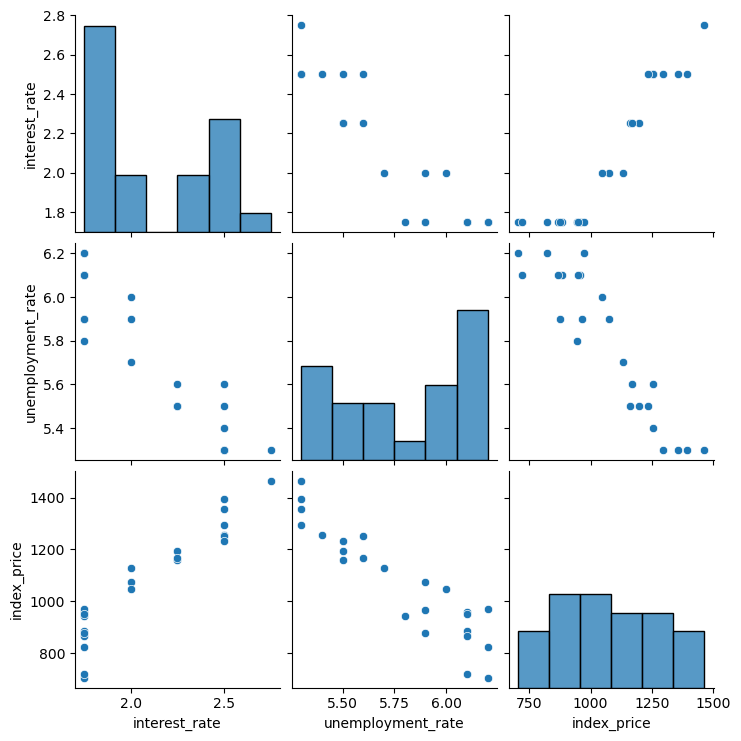

In [59]:
## Lets do some viualization
sns.pairplot(df_index)

In [60]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


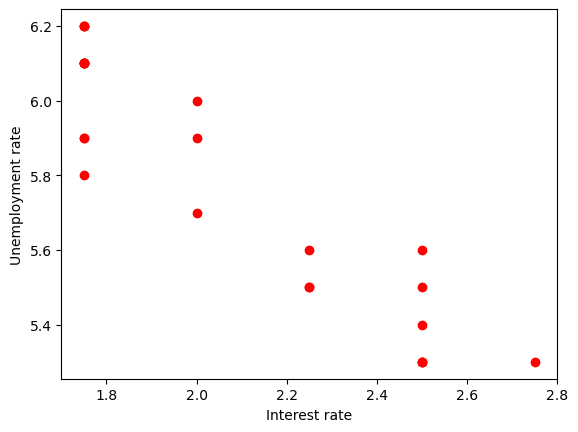

In [61]:
## Visualiza the datapoints more closely
plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='r')
plt.xlabel("Interest rate")
plt.ylabel('Unemployment rate')
plt.show()

In [62]:
df_index

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256
5,2.50,5.6,1254
6,2.50,5.5,1234
7,2.25,5.5,1195
8,2.25,5.5,1159
9,2.25,5.6,1167


In [63]:
##independent and dependent features
x = df_index.iloc[:,:-1]
y = df_index.iloc[:,-1]

In [64]:
x.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [65]:
y

0     1464
1     1394
2     1357
3     1293
4     1256
5     1254
6     1234
7     1195
8     1159
9     1167
10    1130
11    1075
12    1047
13     965
14     943
15     958
16     971
17     949
18     884
19     866
20     876
21     822
22     704
23     719
Name: index_price, dtype: int64

In [66]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [67]:
x_train

,interest_rate,unemployment_rate
9,2.25,5.6
13,1.75,5.9
1,2.50,5.3
21,1.75,6.2
5,2.50,5.6
2,2.50,5.3
12,2.00,6.0
15,1.75,6.1
3,2.50,5.3
4,2.50,5.4


<Axes: xlabel='interest_rate', ylabel='index_price'>

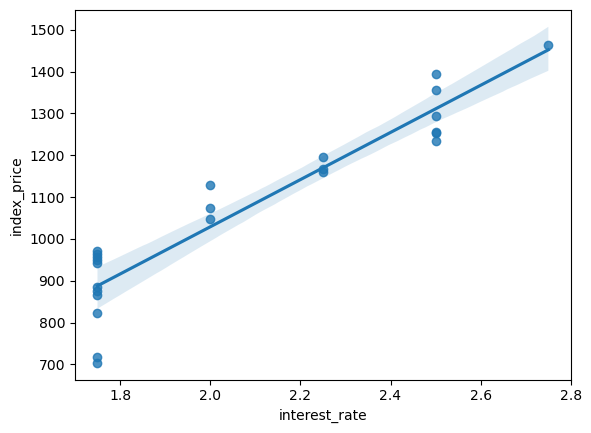

In [68]:
sns.regplot(data=df_index, x=df_index['interest_rate'], y=df_index['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

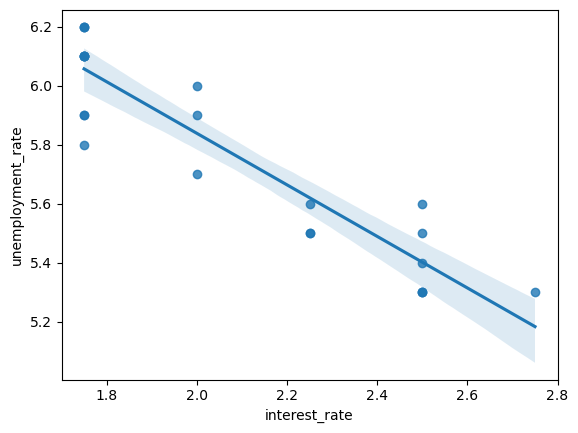

In [69]:
sns.regplot(data=df_index, x=df_index['interest_rate'], y=df_index['unemployment_rate'])

<Axes: xlabel='index_price', ylabel='unemployment_rate'>

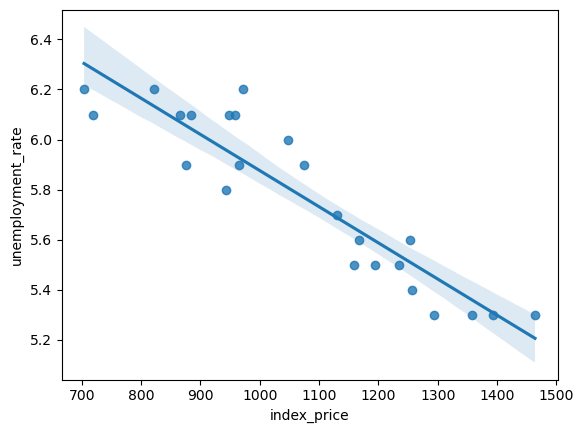

In [70]:
sns.regplot(data=df_index, x=df_index['index_price'], y=df_index['unemployment_rate'])

In [71]:
from sklearn.preprocessing import StandardScaler

In [72]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [73]:
x_train

array([[ 0.55339859, -0.53244666],
       [-0.9486833 ,  0.41597395],
       [ 1.30443953, -1.48086727],
       [-0.9486833 ,  1.36439457],
       [ 1.30443953, -0.53244666],
       [ 1.30443953, -1.48086727],
       [-0.19764235,  0.73211416],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -1.48086727],
       [ 1.30443953, -1.16472707],
       [-0.9486833 ,  1.36439457],
       [-0.9486833 ,  1.04825436],
       [-0.9486833 ,  0.41597395],
       [-0.9486833 ,  1.04825436],
       [ 0.55339859, -0.84858687],
       [-0.19764235, -0.21630646],
       [-0.9486833 ,  0.09983375],
       [-0.9486833 ,  1.04825436],
       [ 1.30443953, -0.84858687]])

In [74]:
from sklearn.linear_model import LinearRegression
regression = LinearRegression()

In [75]:
regression.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [76]:
## prediction
y_pred = regression.predict(x_test)

In [77]:
y_pred

array([1204.14403741,  821.62603274, 1406.38534684,  857.68137178,
        994.85736555])

In [78]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

6957.10530325883
71.71878409976625
83.40926389351982


In [79]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(score)

#display adjusted R-squared
print(1-(1-score)*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1))

0.8254940547158576
0.6509881094317151


## Assumptions

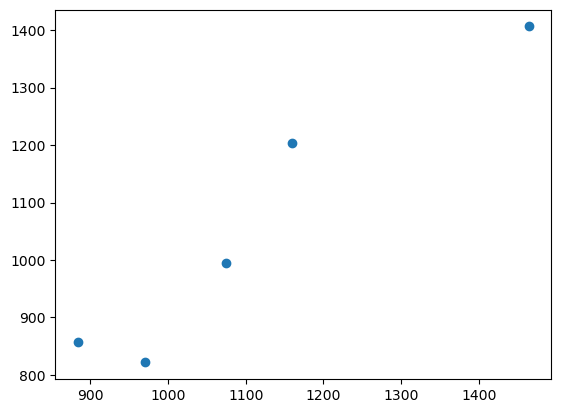

In [80]:
plt.scatter(y_test,y_pred)

In [81]:
residuals = y_test - y_pred
print(residuals)

8     -45.144037
16    149.373967
0      57.614653
18     26.318628
11     80.142634
Name: index_price, dtype: float64


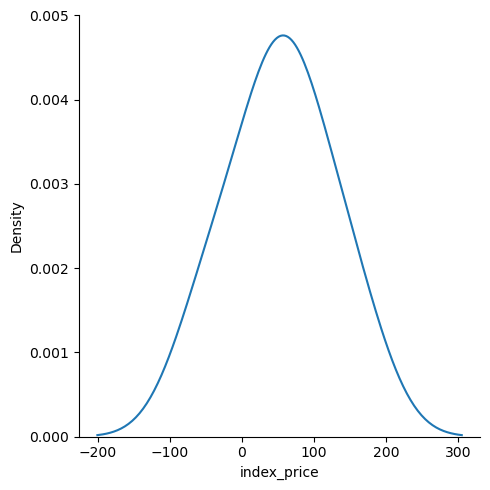

In [82]:
## Plot this residuals
sns.displot(residuals, kind='kde')

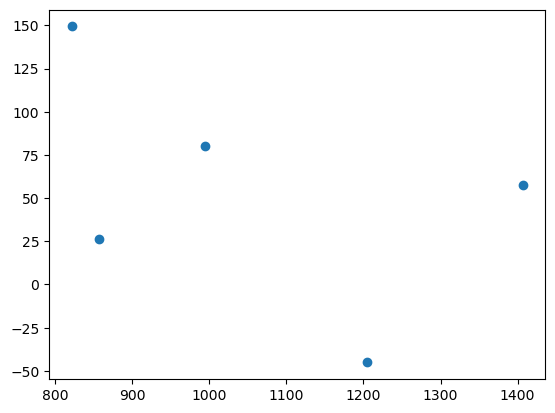

In [83]:
## scatter plot with respect to prediction and residuals
plt.scatter(y_pred,residuals)

In [89]:
# Save these two models for future use
import joblib
joblib.dump(regression,'multiple_linear_regression_model.pkl')
joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [87]:
regressor_loaded = joblib.load('multiple_linear_regression_model.pkl')
scaler_loaded = joblib.load('scaler.pkl')

# Predicting with the loaded model
regressor_loaded.predict(scaler_loaded.transform([[2.5,5]]))

d:\Anocanda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1449.48604832])